these are the imortant library

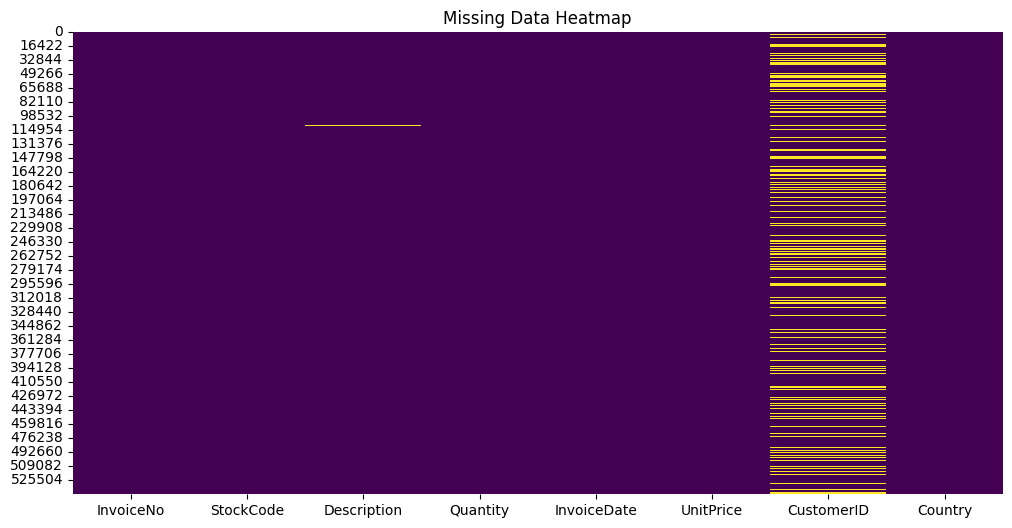

In [91]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the data
df = pd.read_csv("C:/Users/Asus/Downloads/online_retail.csv")

# 2. Create the Heatmap
# This tells seaborn to plot the 'null' (missing) values as white, and the rest as colored
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

# 3. Add labels and show
plt.title('Missing Data Heatmap')
plt.show()

In [92]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [93]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [94]:
df.dropna(subset=['Description'], inplace=True)


In [95]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133626
Country             0
dtype: int64

so in this data sets we have 1.3lack missing values
so we decide to split the data sets in two parts 
df_ml which have not null missing values (uesd for machine learning)
df_full which have all the missing values (used for visulization)
why we split the data into two parts 
because we should find the patterns and flow of the data 

In [96]:
df_full = df 

In [97]:
df_full.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133626
Country             0
dtype: int64

In [98]:
df_full.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [99]:
# 1. Calculate transaction volume by country
# We count the number of InvoiceNo for each country
country_counts = df_full.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=False)


C:\Users\Asus\AppData\Local\Temp\ipykernel_3464\3985437566.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.index, y=country_counts.values, palette='viridis')


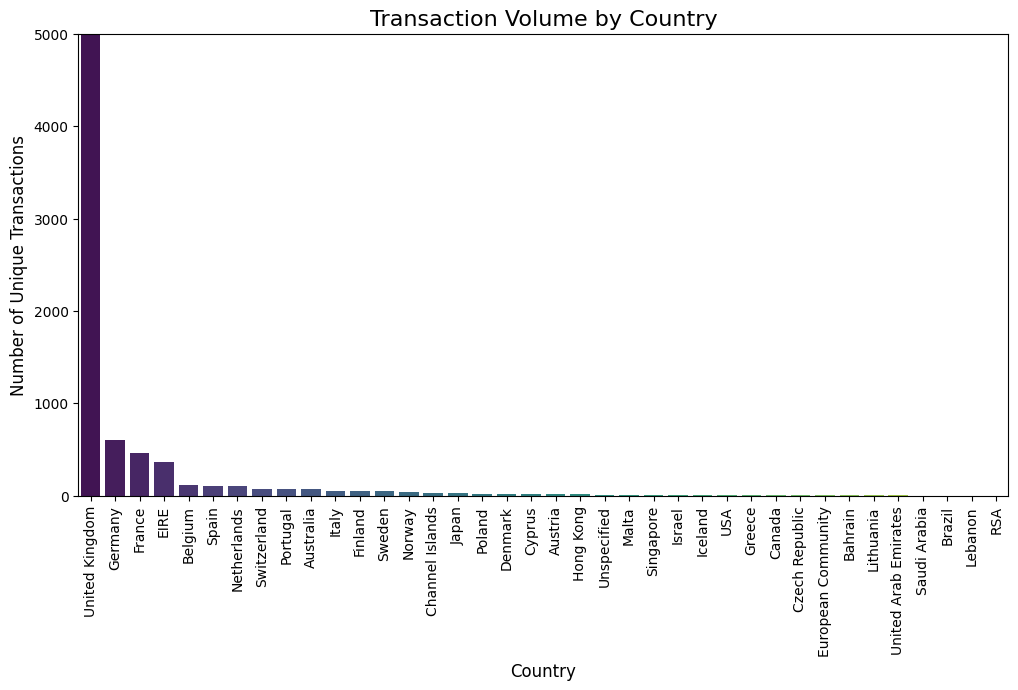

In [100]:
# 2. Plotting the bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=country_counts.index, y=country_counts.values, palette='viridis')

plt.title('Transaction Volume by Country', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Unique Transactions', fontsize=12)
plt.xticks(rotation=90) # Rotate country names so they are readable
plt.ylim(0,5000) # limit the y axis
plt.show()

In [101]:
df_full['UnitPrice'].value_counts()

UnitPrice
1.25       50496
1.65       38181
0.85       28497
2.95       27768
0.42       24533
           ...  
20.53          1
28.68          1
1042.84        1
274.25         1
37.46          1
Name: count, Length: 1630, dtype: int64

C:\Users\Asus\AppData\Local\Temp\ipykernel_3464\2955441278.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='magma')


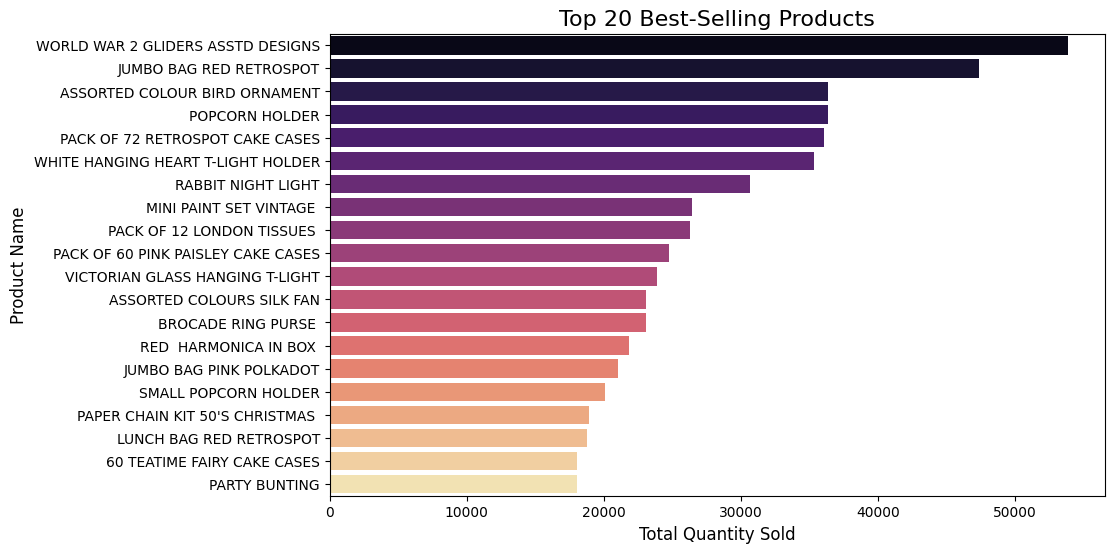

In [102]:
# 1. Group by product name and sum the quantities
# This gives us the total number of items sold for every single product
top_products = df_full.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(20)

# 2. Plotting a horizontal bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='magma')

plt.title('Top 20 Best-Selling Products', fontsize=16)
plt.xlabel('Total Quantity Sold', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.show()

In [103]:
# 1. Ensure InvoiceDate is in datetime format
df_full['InvoiceDate'] = pd.to_datetime(df_full['InvoiceDate'])

In [104]:
df_full['revenue']= df_full['Quantity']*df_full['UnitPrice']

In [105]:
df_full.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [106]:
#3. Group data by Month
# We use 'ME' (Month End) to aggregate data into monthly chunks
monthly_sales = df_full.set_index('InvoiceDate').resample('ME')['revenue'].sum()


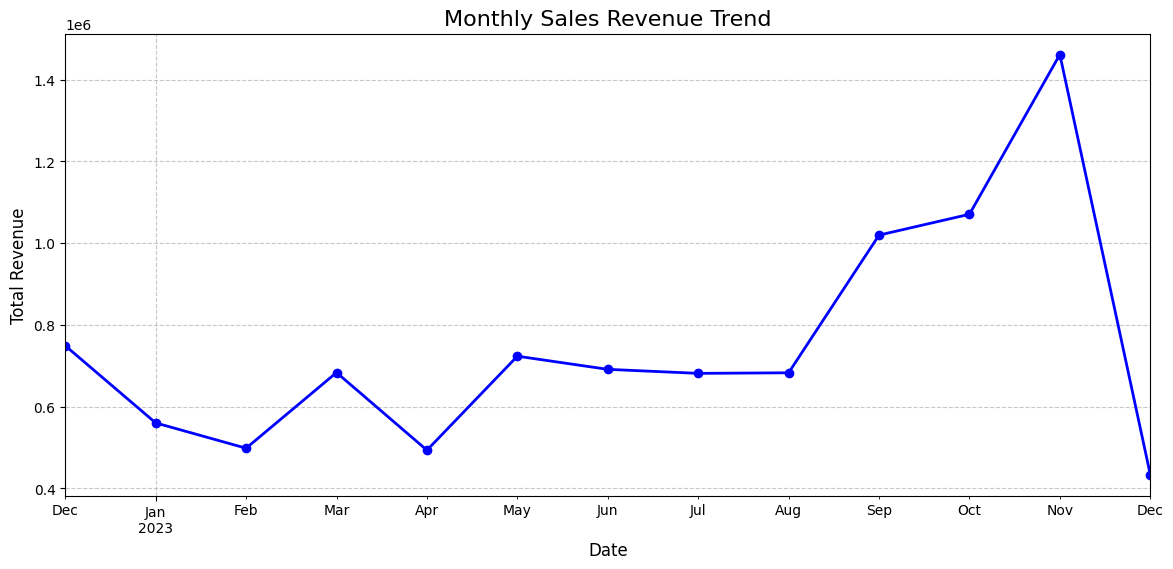

In [107]:
# 4. Plotting the line chart
plt.figure(figsize=(14, 6))
monthly_sales.plot(kind='line', marker='o', color='b', linewidth=2)

plt.title('Monthly Sales Revenue Trend', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

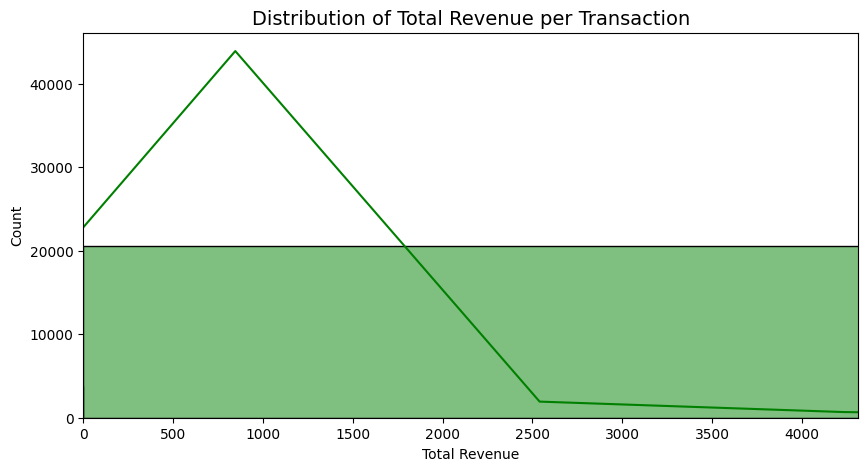

In [108]:

# 2. Distribution of Total Revenue per transaction
transaction_revenue = df.groupby('InvoiceNo')['revenue'].sum()

plt.figure(figsize=(10, 5))
sns.histplot(transaction_revenue, bins=50, kde=True, color='green')
plt.title('Distribution of Total Revenue per Transaction', fontsize=14)
plt.xlabel('Total Revenue')
plt.xlim(0, transaction_revenue.quantile(0.99)) # Limiting x-axis to 99th percentile to remove extreme outliers
plt.show()

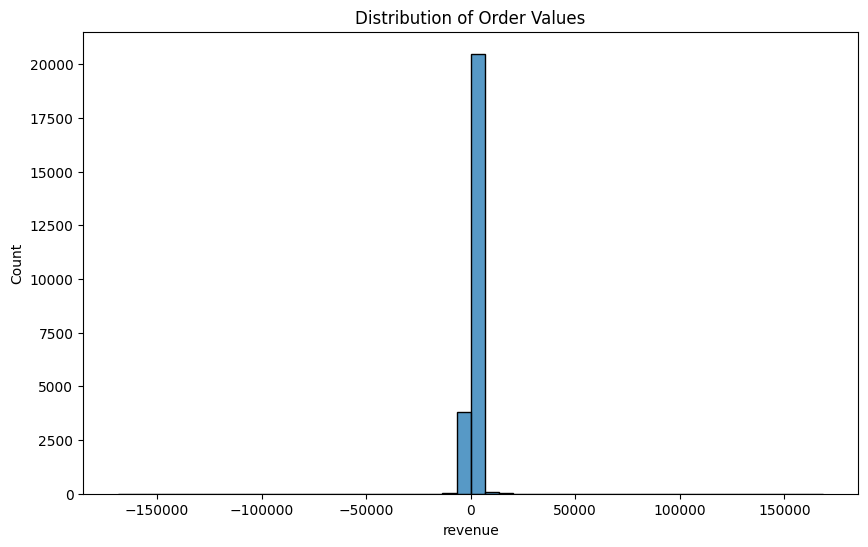

In [109]:
#group by the invoiceno and sum to the revenue to calulate the how much revenue is generated in a particulat transiction id
order_value = (
    df_full.groupby('InvoiceNo')['revenue']
           .sum()
)

plt.figure(figsize=(10,6))
sns.histplot(order_value, bins=50)
plt.title('Distribution of Order Values')
plt.show()

In [110]:
print(order_value.describe())

count     24446.000000
mean        398.746132
std        2070.116203
min     -168469.600000
25%          50.000000
50%         229.500000
75%         426.600000
max      168469.600000
Name: revenue, dtype: float64


so we analyze that in our revenue columns there are some negative revenue 
in our invoice no some transition are cancled  and return

In [111]:
print(order_value.min())
print(order_value.max())

-168469.6
168469.6


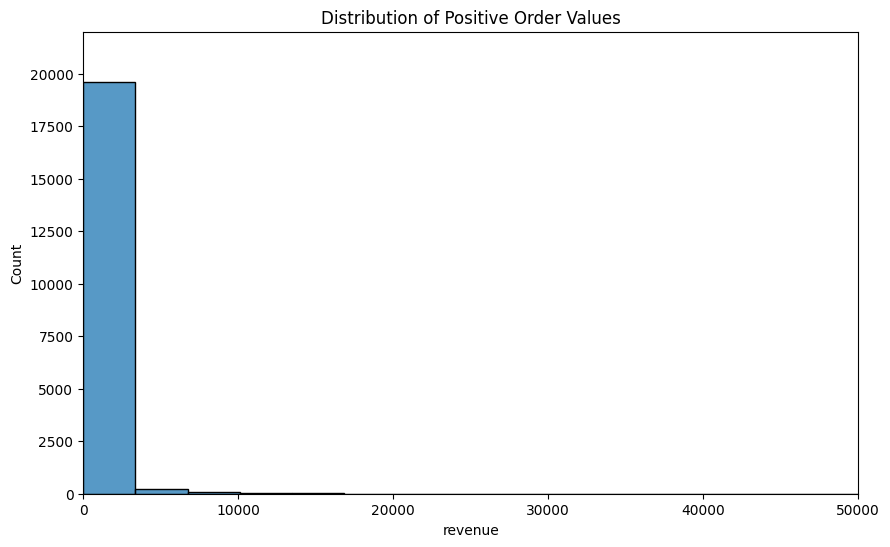

In [112]:

order_value_clean = order_value[order_value > 0]

plt.figure(figsize=(10,6))
sns.histplot(order_value_clean, bins=50)

plt.title('Distribution of Positive Order Values')
plt.xlim(0,50000)
plt.ylim(0,22000)
plt.show()

In [113]:
df_full[df_full['UnitPrice'] <= 0].shape

(1063, 9)

In [114]:
df_full[df_full['Quantity'] < 0].shape

(9762, 9)

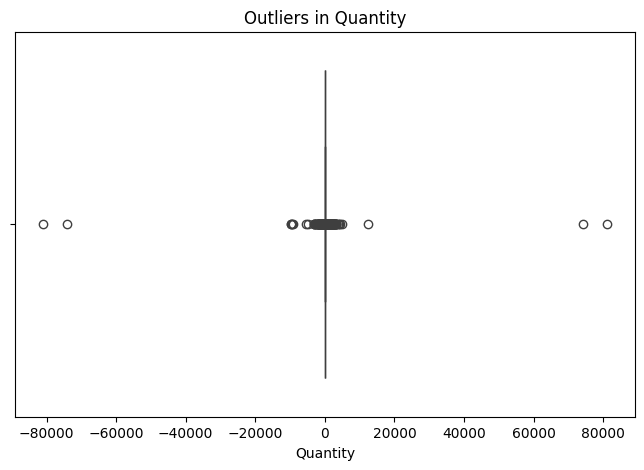

In [115]:
#so this code tells the outlier in quantity columns
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x=df_full['Quantity'])

plt.title('Outliers in Quantity')
plt.show()

so u can cleary see that most of thr quantity lies b/w 0 to 10
but some point  have far away the lines these are the outlier 
one point is lies in 80000 and one is -80000 thousand 
because the revenue of a specific quantity have purchasing more  basicaly in bulking 

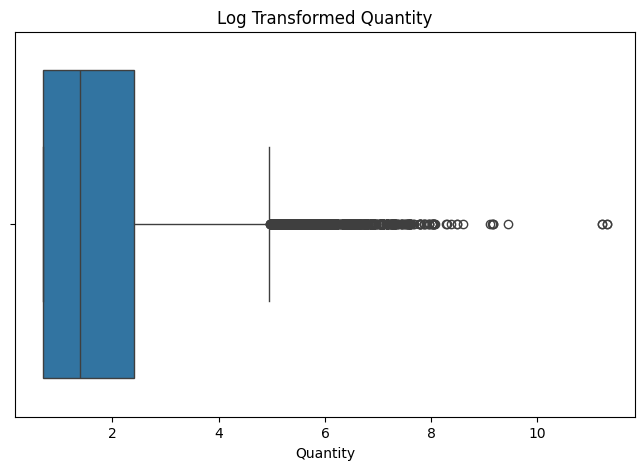

In [116]:
# so first we remove the negative values temperary and see the revanue in postive values
plt.figure(figsize=(8,5))
sns.boxplot(x=np.log1p(df_full['Quantity'].abs())) # .abs convert the negative value into positive

plt.title('Log Transformed Quantity')
plt.show()

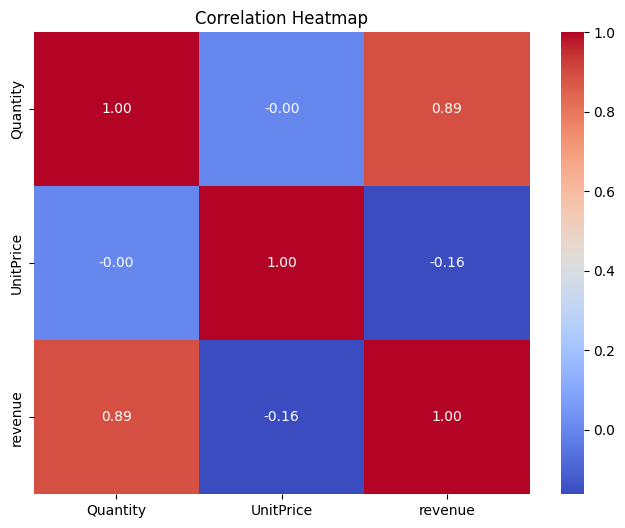

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['Quantity', 'UnitPrice', 'revenue']

corr_matrix = df_full[num_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

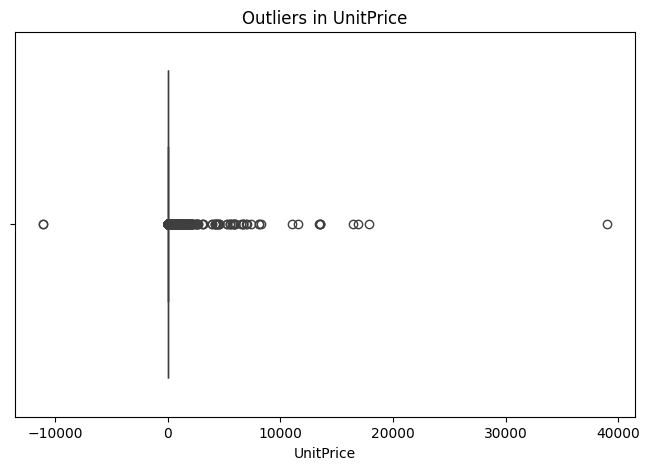

In [118]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_full['UnitPrice'])

plt.title('Outliers in UnitPrice')
plt.show()

They may represent data entry errors (negative prices)
Or they could be legitimate rare cases (luxury items with very high prices)
Several scattered between 0 and 20,000
One extreme outlier near 40,000
One unusual negative outlier near -10,000 (which is suspicious, since prices shouldn’t normally be negative).

NOW WE CAN SEE THE TRENDS AND PATTERNS OF THE DATA 

USEFULL INSIGHT IN THE DATA
1. IN OUR DATA SETS WE HAVE APROX 5 LACK ENRTYES
2. OUR DATA HAVE APROX 1.3LACK MISSING VALUES 
3. IN THIS DATA SETS MOST OF THE PRODUCT IS BELONGS IN UNITED KINGDOM COUNTRY.IT DOMINATE ALL THR COUNTRY
4. MOST OF THE PRODUCT IN RANGE OF (1,200) DOLLAR IN UNITE PRICE 
5. MOST OF THE REVENUE IS GENERATED IN THE MONTH OF (OCT TO DEC) ABOUT MORE THAN 15 LACK
6. I ALSO FIND THE TOP 20 MOST PURCHASE PRODUCT. IT IS ABOUT MORE THAN 50 THOUSAND QUANTITY 
7. IN THE DATA SET SOME ENTRYES ARE DUPLICATE 
8. I ALSO FIND THE CORRELATION B/W THE COLUMNS 
9. THE CORR B/W QUANTITY AND UNITE PRICE IS POSTITIVELY CORRELATE MEAN IF ONE ENTITY IS INCREASE THE ANOTHER WILL INCREASE AUTOMATICLY
10. IF OUR PRODUCT HAVE LOW PRICE AND SELL IN UK IN THE MONTH OF NOV AND DEC THE PRODUCT GOES TO ITS MAXIMUN


In [119]:
df_ml= df_full.copy()

In [120]:
df_ml = df_ml[df_ml['Quantity'] > 0]

In [121]:
df_ml = df_ml[df_ml['UnitPrice'] > 0]

In [122]:
df_ml = df_ml.dropna(subset=['CustomerID'])

In [123]:
df_ml.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [177]:
df_ml.shape

(397884, 9)

In [176]:
df_ml.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
revenue        0
dtype: int64

In [178]:
df_ml.duplicated().sum()

np.int64(5192)

In [179]:
df_ml.drop_duplicates

<bound method DataFrame.drop_duplicates of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  Unit

In [134]:
df_ml['UnitPrice'].max()

np.float64(8142.75)

In [135]:
df_ml['Quantity'].min()

np.int64(1)

In [136]:
df_ml = df_ml.dropna(subset=['CustomerID'])

In [137]:
df_ml['CustomerID'].isnull().sum()

np.int64(0)

In [138]:
df_ml['revenue'] = df_ml['Quantity'] * df_ml['UnitPrice']

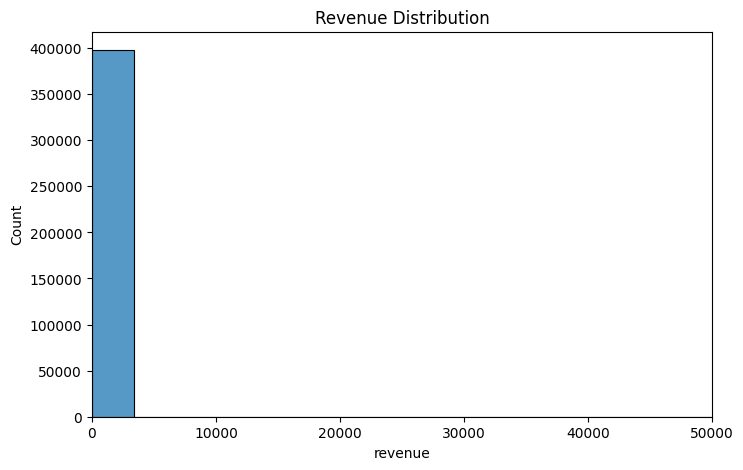

In [140]:
plt.figure(figsize=(8,5))
sns.histplot(df_ml['revenue'], bins=50)

plt.title("Revenue Distribution")
plt.xlim(0,50000)
plt.show()

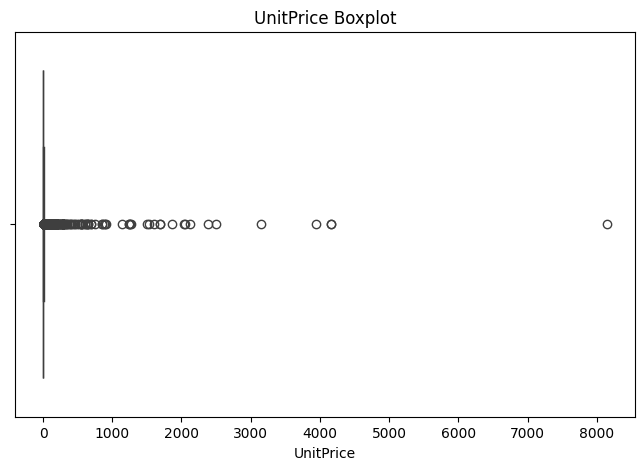

In [143]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_ml['UnitPrice'])

plt.title("UnitPrice Boxplot")
plt.show()

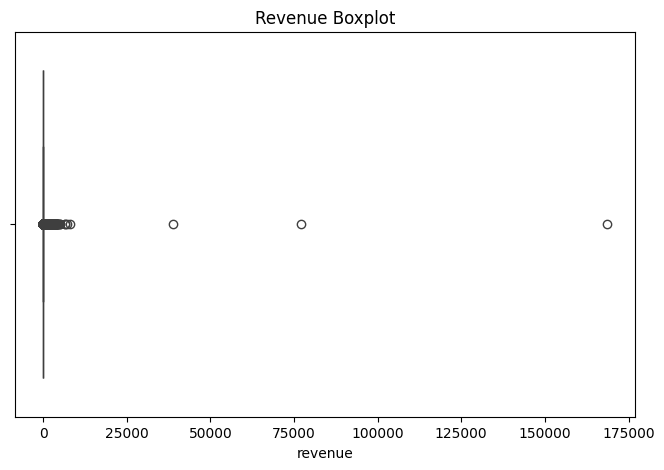

In [144]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_ml['revenue'])

plt.title("Revenue Boxplot")
plt.show()

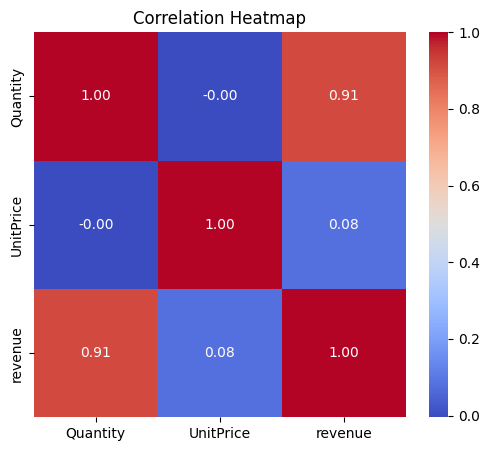

In [145]:
corr = df_ml[['Quantity','UnitPrice','revenue']].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

In [146]:
reference_date = df_ml['InvoiceDate'].max() + pd.Timedelta(days=1)

print(reference_date)

2023-12-10 12:50:00


In [147]:
rfm = df_ml.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'revenue': 'sum'
})

In [148]:
rfm

,InvoiceDate,InvoiceNo,revenue
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
...,...,...,...
18280.0,278,1,180.60
18281.0,181,1,80.82
18282.0,8,2,178.05


In [149]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [150]:
rfm

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
...,...,...,...
18280.0,278,1,180.60
18281.0,181,1,80.82
18282.0,8,2,178.05


In [151]:
print(rfm.shape)

rfm.describe()

(4338, 3)


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [152]:
rfm.isnull().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

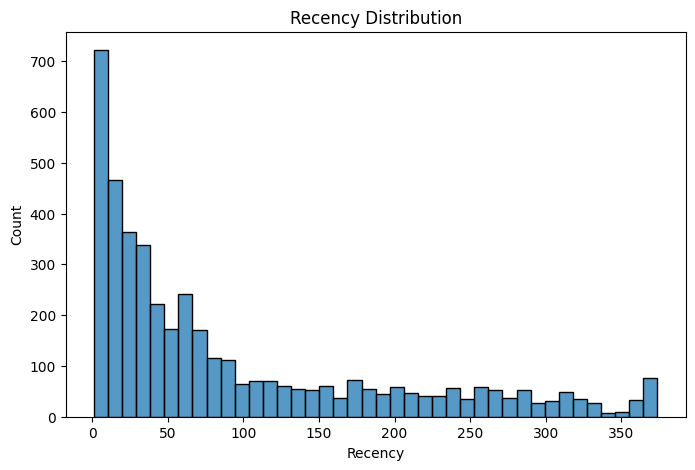

In [153]:
plt.figure(figsize=(8,5))
sns.histplot(rfm['Recency'], bins=40)
plt.title("Recency Distribution")
plt.show()

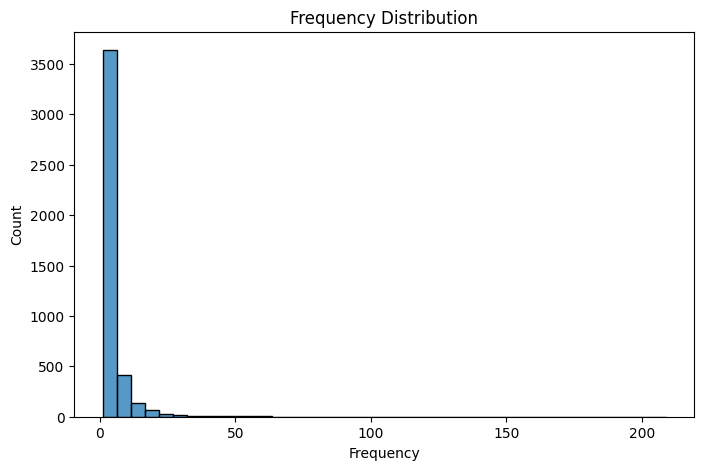

In [154]:
plt.figure(figsize=(8,5))
sns.histplot(rfm['Frequency'], bins=40)
plt.title("Frequency Distribution")
plt.show()

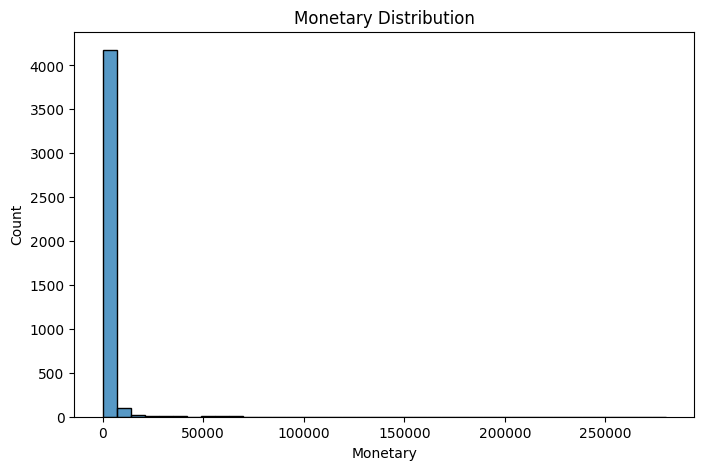

In [158]:
plt.figure(figsize=(8,5))
sns.histplot(rfm['Monetary'], bins=40)
plt.title("Monetary Distribution")
plt.show()

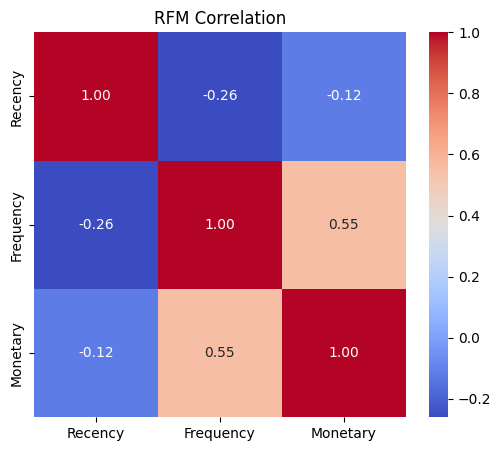

In [159]:
plt.figure(figsize=(6,5))

sns.heatmap(
    rfm.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("RFM Correlation")
plt.show()

In [160]:
from sklearn.preprocessing import StandardScaler

In [161]:
scaler = StandardScaler()

In [162]:
rfm_scaled = scaler.fit_transform(rfm)

In [163]:
from sklearn.cluster import KMeans

c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1036, in

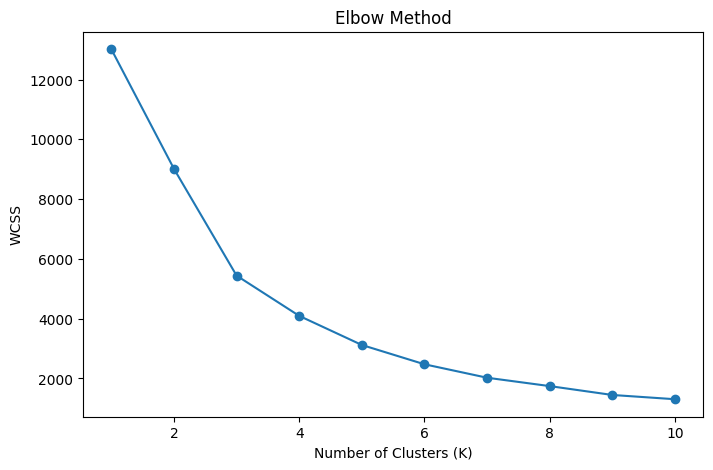

In [164]:
cluster_scores = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    cluster_scores.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), cluster_scores, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

In [165]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans.fit(rfm_scaled)

KMeans(n_clusters=4, n_init=10, random_state=42)

In [166]:
rfm['Cluster'] = kmeans.labels_

In [167]:
rfm

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1
...,...,...,...,...
18280.0,278,1,180.60,1
18281.0,181,1,80.82,1
18282.0,8,2,178.05,0


In [168]:
rfm['Cluster'].value_counts()

Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64

In [169]:
rfm.shape

(4338, 4)

C:\Users\Asus\AppData\Local\Temp\ipykernel_3464\401592234.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


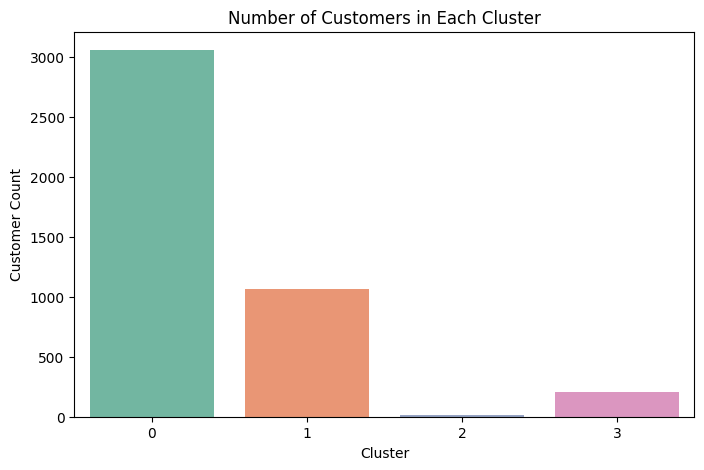

In [170]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Cluster',
    data=rfm,
    palette='Set2'
)

plt.title('Number of Customers in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Customer Count')

plt.show()

cluster_0 means= Regular Customers(Average spending and average purchase frequency)
cluster_1 means= Lost Customers(Haven't purchased for a long time)
cluster_2 means= VIP Customers(High spending, frequent, and recent purchases)
cluster_3 means= Loyal Customers(Recent and frequent buyers with good spending)

In [174]:
df_ml.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [187]:
df_ml.shape

(397884, 9)

In [188]:
df_ml = df_full.copy()

df_ml = df_ml[['CustomerID', 'Description', 'Quantity']]

In [189]:
df_ml.shape

(540455, 3)

In [191]:
df_ml.isnull().sum()

CustomerID     133626
Description         0
Quantity            0
dtype: int64

In [192]:
df_ml = df_ml.dropna(subset=['CustomerID'])

In [193]:
df_ml.isnull().sum()

CustomerID     0
Description    0
Quantity       0
dtype: int64

In [195]:
df_ml = df_ml[df_ml['Quantity'] > 0]

In [196]:
df_ml['Quantity'].min()

np.int64(1)

In [197]:
customer_product_matrix = df_ml.pivot_table(
    index='CustomerID',
    columns='Description',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

In [198]:
print(customer_product_matrix.shape)

customer_product_matrix.head()

(4339, 3877)


Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12347.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12349.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12350.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [199]:
customer_product_matrix.shape

(4339, 3877)

In [200]:
product_matrix = customer_product_matrix.T

In [205]:
from sklearn.metrics.pairwise import cosine_similarity

In [207]:

cosine_sim_df = pd.DataFrame(
    cosine_sim,
    index=product_matrix.index,
    columns=product_matrix.index
)

In [208]:
print(cosine_sim_df.shape)

cosine_sim_df.head()

(3877, 3877)


Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Description,,,,,,,,,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,1.000000,0.000000,0.000021,0.000227,0.000000,0.000000,0.020155,0.000000,0.000262,0.063396,...,0.0,0.001368,0.015886,0.001767,0.0,0.002846,0.0,0.013128,0.000000,0.002594
50'S CHRISTMAS GIFT BAG LARGE,0.000000,1.000000,0.003533,0.004001,0.000000,0.020034,0.027433,0.900849,0.119031,0.013380,...,0.0,0.001718,0.015572,0.018032,0.0,0.015710,0.0,0.011238,0.000000,0.029793
DOLLY GIRL BEAKER,0.000021,0.003533,1.000000,0.870851,0.980561,0.006296,0.005302,0.003034,0.001765,0.411331,...,0.0,0.000043,0.002869,0.344923,0.0,0.525860,0.0,0.822946,0.000097,0.006665
I LOVE LONDON MINI BACKPACK,0.000227,0.004001,0.870851,1.000000,0.883883,0.019879,0.004904,0.004043,0.008270,0.382056,...,0.0,0.001409,0.004197,0.310017,0.0,0.471717,0.0,0.749210,0.000000,0.010393
I LOVE LONDON MINI RUCKSACK,0.000000,0.000000,0.980561,0.883883,1.000000,0.000000,0.000000,0.000000,0.000000,0.410578,...,0.0,0.000000,0.000000,0.347021,0.0,0.530836,0.0,0.837170,0.000000,0.000000


In [209]:
def recommend_products(product_name, top_n=5):

    # Check whether the product exists
    if product_name not in cosine_sim_df.index:
        return "Product not found."

    # Get similarity scores
    similar_products = cosine_sim_df[product_name]

    # Sort from highest to lowest similarity
    similar_products = similar_products.sort_values(ascending=False)

    # Remove the product itself and keep the top N
    recommendations = similar_products.iloc[1:top_n+1]

    return recommendations

In [210]:
recommend_products("WHITE HANGING HEART T-LIGHT HOLDER")

Description
GIN + TONIC DIET METAL SIGN         0.750410
RED HANGING HEART T-LIGHT HOLDER    0.658719
WASHROOM METAL SIGN                 0.643500
LAUNDRY 15C METAL SIGN              0.642206
GREEN VINTAGE SPOT BEAKER           0.631461
Name: WHITE HANGING HEART T-LIGHT HOLDER, dtype: float64

In [211]:
recommend_products("DOLLY GIRL BEAKER")

'Product not found.'

In [212]:
import pickle

In [213]:
print(type(cosine_sim_df))
print(type(product_matrix))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [214]:
artifacts = {
    "similarity_matrix": cosine_sim_df,
    "product_names": cosine_sim_df.index.tolist()
}

In [215]:
with open("recommendation_model.pkl", "wb") as file:
    pickle.dump(artifacts, file)

print("Model Saved Successfully!")

Model Saved Successfully!


In [216]:
import os

os.listdir()

['3c631b164c',
 '41dd792b5e',
 '6928394f91',
 'bin',
 'Code.exe',
 'Code.VisualElementsManifest.xml',
 'fcf604774b',
 'new_Code.exe',
 'new_Code.VisualElementsManifest.xml',
 'recommendation_model.pkl',
 'unins000.dat',
 'unins000.exe',
 'unins000.msg',
 'updating_version']

In [217]:
with open("recommendation_model.pkl", "rb") as file:
    model = pickle.load(file)

In [218]:
cosine_sim_df = model["similarity_matrix"]

products = model["product_names"]

In [219]:
print(type(cosine_sim_df))

print(type(products))

print(products[:10])

<class 'pandas.core.frame.DataFrame'>
<class 'list'>
[' 4 PURPLE FLOCK DINNER CANDLES', " 50'S CHRISTMAS GIFT BAG LARGE", ' DOLLY GIRL BEAKER', ' I LOVE LONDON MINI BACKPACK', ' I LOVE LONDON MINI RUCKSACK', ' NINE DRAWER OFFICE TIDY', ' OVAL WALL MIRROR DIAMANTE ', ' RED SPOT GIFT BAG LARGE', ' SET 2 TEA TOWELS I LOVE LONDON ', ' SPACEBOY BABY GIFT SET']


In [220]:
def recommend_products(product_name, top_n=5):

    if product_name not in cosine_sim_df.index:
        return "Product not found."

    recommendations = (
        cosine_sim_df[product_name]
        .sort_values(ascending=False)
        .iloc[1:top_n+1]
        .reset_index()
    )

    recommendations.columns = [
        "Recommended Product",
        "Similarity Score"
    ]

    return recommendations

In [222]:
recommend_products("ZINC T-LIGHT HOLDER STARS SMALL")

,Recommended Product,Similarity Score
0,ZINC T-LIGHT HOLDER STAR LARGE,0.585205
1,ZINC HEART LATTICE T-LIGHT HOLDER,0.544126
2,EMBROIDERED RIBBON REEL REBECCA,0.538747
3,GINGHAM HEART DECORATION,0.536769
4,FOLDING BUTTERFLY MIRROR RED,0.536624
